In [2]:
import pandas as pd

creditos = pd.read_spss("../data/ECV6R_CREDITOS.SAV")



In [3]:
creditos.shape

(5687, 27)

In [4]:
creditos.isnull().sum()

IDENTIF_SECT       0
IDENTIF_HOG        0
AREA_5000          0
AREA_2000          0
CIUDAD_AUTO     4666
PROVINCIA          0
ZDP                0
REGION             0
CIUDAD             0
ZONA               0
SECTOR             0
VIVIENDA           0
HOGAR              0
PERIODO            0
CR00               0
CR02               0
CR03               0
CR04               0
CR05               0
CR06               0
CR07               0
CR08               0
CR09               0
CR10               0
FEXP               0
REGIONAL           0
FASE               0
dtype: int64

In [5]:
creditos = creditos.drop_duplicates()

In [6]:
creditos.shape

(5687, 27)

In [7]:
creditos.info()

<class 'pandas.DataFrame'>
RangeIndex: 5687 entries, 0 to 5686
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   IDENTIF_SECT  5687 non-null   str     
 1   IDENTIF_HOG   5687 non-null   str     
 2   AREA_5000     5687 non-null   category
 3   AREA_2000     5687 non-null   category
 4   CIUDAD_AUTO   1021 non-null   category
 5   PROVINCIA     5687 non-null   category
 6   ZDP           5687 non-null   category
 7   REGION        5687 non-null   category
 8   CIUDAD        5687 non-null   float64 
 9   ZONA          5687 non-null   float64 
 10  SECTOR        5687 non-null   float64 
 11  VIVIENDA      5687 non-null   float64 
 12  HOGAR         5687 non-null   float64 
 13  PERIODO       5687 non-null   category
 14  CR00          5687 non-null   float64 
 15  CR02          5687 non-null   category
 16  CR03          5687 non-null   category
 17  CR04          5687 non-null   category
 18  CR05          5687 

In [8]:
creditos.to_csv("../data/processed/creditos_limpios.csv", index=False)

OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [9]:
print("Base limpia guardada correctamente.")

Base limpia guardada correctamente.


In [10]:
import os

print(os.listdir("../data"))

['ECV6R_AGRO1.SAV', 'ECV6R_AGRO_PARTE_AI.SAV', 'ECV6R_AGRO_PARTE_AII.SAV', 'ECV6R_AGRO_PARTE_B.SAV', 'ECV6R_AGRO_PARTE_C_D.SAV', 'ECV6R_AGRO_PARTE_E.SAV', 'ECV6R_AGRO_PARTE_E_IIIA.SAV', 'ECV6R_AGRO_PARTE_E_IV.SAV', 'ECV6R_AGRO_PARTE_E_V_F_G.SAV', 'ECV6R_CAPITAL_SOCIAL.SAV', 'ECV6R_CREDITOS.SAV', 'ECV6R_CREDITOS1.SAV', 'ECV6R_EQUIPAMIENTO.SAV', 'ECV6R_GASTOS_ALIMENTOS.SAV', 'ECV6R_GASTOS_ALIMENTOS1.SAV', 'ECV6R_NEGOCIOS.SAV', 'ECV6R_NEGOCIOS1.SAV', 'ECV6R_OTROS_GASTOS.SAV', 'ECV6R_OTROS_INGRESOS.SAV', 'ECV6R_PERSONAS.SAV', 'ECV6R_PRESTAMOS.SAV', 'ECV6R_PRESTAMOS1.SAV', 'ECV6R_VIVIENDA.SAV', 'ecv_fexp_fin.sav', 'Nota aclaratoria.pdf', 'processed', 'raw']


In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
personas = pd.read_spss(
    "../data/raw/ECV6R_PERSONAS.SAV",
    convert_categoricals=True
)

print(personas.shape)

(109694, 684)


In [3]:
personas["trabaja"] = np.where(
    personas["PA01"] == "Trabajó al menos una hora",
    1,
    np.where(
        personas["PA01"] == "No trabajó",
        0,
        np.nan
    )
)

print(personas["trabaja"].value_counts(dropna=False))

trabaja
1.0    52491
0.0    33459
NaN    23744
Name: count, dtype: int64


In [4]:
modelo = personas[
    ["trabaja", "SEXO", "EDAD", "PE47", "AREA_5000", "FEXP"]
].copy()

modelo["SEXO"] = modelo["SEXO"].astype(str)
modelo["EDAD"] = pd.to_numeric(
    modelo["EDAD"].astype(str),
    errors="coerce"
)

modelo["hombre"] = (
    modelo["SEXO"] == "Hombre"
).astype(int)

modelo["edad2"] = modelo["EDAD"] ** 2

modelo = modelo.dropna()

print("Observaciones:", len(modelo))

Observaciones: 85919


In [5]:
modelo = pd.get_dummies(
    modelo,
    columns=["PE47", "AREA_5000"],
    drop_first=True,
    dtype=int
)

print(modelo.columns.tolist())

['trabaja', 'SEXO', 'EDAD', 'FEXP', 'hombre', 'edad2', 'PE47_Educación Media o Bachillerato', 'PE47_Educación básica', 'PE47_Educación inicial', 'PE47_Ninguno', 'PE47_Post Bachillerato / Sup. No Universitario', 'PE47_Postgrado', 'PE47_Primaria', 'PE47_Secundaria', 'PE47_Superior', 'AREA_5000_Urbano']


In [6]:
y = modelo["trabaja"].astype(int)

X = modelo.drop(
    columns=["trabaja", "SEXO", "FEXP"]
)

X = sm.add_constant(X)

X = X.astype(float)

print("Y:", y.shape)
print("X:", X.shape)
print(X.head())

Y: (85919,)
X: (85919, 14)
   const  EDAD  hombre   edad2  PE47_Educación Media o Bachillerato  \
0    1.0  39.0     0.0  1521.0                                  0.0   
1    1.0  13.0     1.0   169.0                                  0.0   
2    1.0  36.0     1.0  1296.0                                  0.0   
3    1.0  36.0     0.0  1296.0                                  0.0   
4    1.0  18.0     1.0   324.0                                  0.0   

   PE47_Educación básica  PE47_Educación inicial  PE47_Ninguno  \
0                    0.0                     0.0           0.0   
1                    1.0                     0.0           0.0   
2                    0.0                     0.0           0.0   
3                    0.0                     0.0           0.0   
4                    0.0                     0.0           0.0   

   PE47_Post Bachillerato / Sup. No Universitario  PE47_Postgrado  \
0                                             0.0             0.0   
1          

In [7]:
logit_model = sm.Logit(y, X)

logit_result = logit_model.fit(
    maxiter=100
)

print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.481191
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                          Logit   Df Residuals:                    85905
Method:                           MLE   Df Model:                           13
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2800
Time:                        19:34:30   Log-Likelihood:                -41343.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

In [8]:
probit_model = sm.Probit(y, X)

probit_result = probit_model.fit(
    maxiter=100
)

print(probit_result.summary())

Optimization terminated successfully.
         Current function value: 0.481005
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:                trabaja   No. Observations:                85919
Model:                         Probit   Df Residuals:                    85905
Method:                           MLE   Df Model:                           13
Date:                Mon, 03 Aug 2026   Pseudo R-squ.:                  0.2803
Time:                        19:34:40   Log-Likelihood:                -41327.
converged:                       True   LL-Null:                       -57423.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
const                               

In [9]:
comparacion = pd.DataFrame({
    "Modelo": ["Logit", "Probit"],
    "AIC": [
        logit_result.aic,
        probit_result.aic
    ],
    "BIC": [
        logit_result.bic,
        probit_result.bic
    ],
    "Pseudo_R2": [
        logit_result.prsquared,
        probit_result.prsquared
    ]
})

comparacion

,Modelo,AIC,BIC,Pseudo_R2
0,Logit,82714.877053,82845.933297,0.280024
1,Probit,82682.950542,82814.006786,0.280302


In [10]:
marginales_logit = logit_result.get_margeff(
    at="overall"
)

print(marginales_logit.summary())

        Logit Marginal Effects       
Dep. Variable:                trabaja
Method:                          dydx
At:                           overall
                                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
EDAD                                               0.0380      0.000     88.532      0.000       0.037       0.039
hombre                                             0.2034      0.003     77.377      0.000       0.198       0.209
edad2                                             -0.0004    4.4e-06    -93.667      0.000      -0.000      -0.000
PE47_Educación Media o Bachillerato               -0.1073      0.015     -7.250      0.000      -0.136      -0.078
PE47_Educación básica                             -0.1600      0.015    -10.697      0.000      -0.189      -0.131
PE47_Educación inicial                     

In [11]:
marginales_probit = probit_result.get_margeff(
    at="overall"
)

print(marginales_probit.summary())

       Probit Marginal Effects       
Dep. Variable:                trabaja
Method:                          dydx
At:                           overall
                                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
EDAD                                               0.0379      0.000     88.233      0.000       0.037       0.039
hombre                                             0.2037      0.003     78.920      0.000       0.199       0.209
edad2                                             -0.0004   4.36e-06    -94.308      0.000      -0.000      -0.000
PE47_Educación Media o Bachillerato               -0.1086      0.014     -7.570      0.000      -0.137      -0.080
PE47_Educación básica                             -0.1648      0.015    -11.364      0.000      -0.193      -0.136
PE47_Educación inicial                     

In [12]:
modelo["prob_logit"] = logit_result.predict(X)
modelo["prob_probit"] = probit_result.predict(X)

print(
    modelo[
        ["trabaja", "prob_logit", "prob_probit"]
    ].head()
)

   trabaja  prob_logit  prob_probit
0      1.0    0.681734     0.677229
1      1.0    0.199445     0.205370
2      1.0    0.872260     0.871828
3      1.0    0.651483     0.648446
4      0.0    0.574269     0.575770


In [13]:
modelo["pred_logit"] = (
    modelo["prob_logit"] >= 0.5
).astype(int)

matriz = confusion_matrix(
    modelo["trabaja"],
    modelo["pred_logit"]
)

print("Matriz de confusión:")
print(matriz)

print(
    "\nAccuracy:",
    accuracy_score(
        modelo["trabaja"],
        modelo["pred_logit"]
    )
)

Matriz de confusión:
[[21423 12008]
 [ 7418 45070]]

Accuracy: 0.773903327552695


In [14]:
fpr, tpr, thresholds = roc_curve(
    modelo["trabaja"],
    modelo["prob_logit"]
)

auc_logit = roc_auc_score(
    modelo["trabaja"],
    modelo["prob_logit"]
)

auc_probit = roc_auc_score(
    modelo["trabaja"],
    modelo["prob_probit"]
)

print("AUC Logit:", round(auc_logit, 4))
print("AUC Probit:", round(auc_probit, 4))

AUC Logit: 0.837
AUC Probit: 0.837


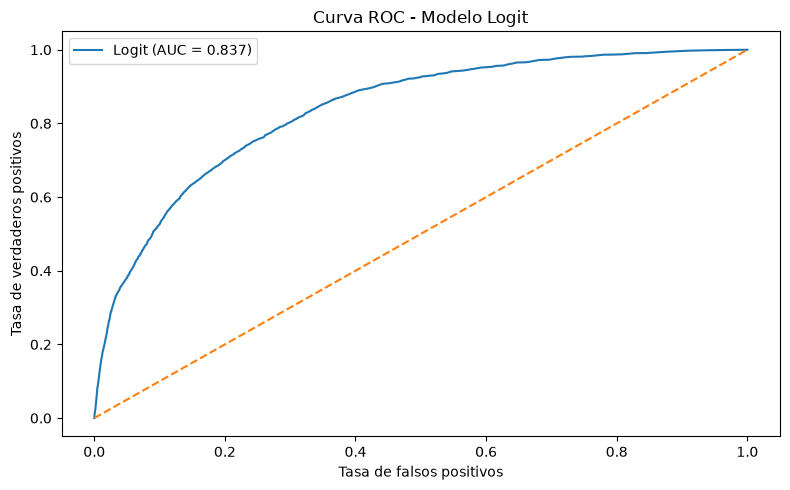

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logit (AUC = {auc_logit:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo Logit")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.drop(columns=["const"])

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif.sort_values(
    "VIF",
    ascending=False
)

,Variable,VIF
0,EDAD,114.087923
2,edad2,44.079619
9,PE47_Primaria,11.881088
10,PE47_Secundaria,8.101994
11,PE47_Superior,4.517503
4,PE47_Educación básica,3.364829
6,PE47_Ninguno,2.757718
3,PE47_Educación Media o Bachillerato,2.697531
12,AREA_5000_Urbano,2.116956
1,hombre,1.965479


In [17]:
import os

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/results", exist_ok=True)

print("Carpetas listas.")

FileExistsError: [WinError 183] No se puede crear un archivo que ya existe: '../outputs/figures'

In [18]:
comparacion.to_csv(
    "../outputs/tables/comparacion_modelos.csv",
    index=False
)

pd.DataFrame({
    "coeficiente": logit_result.params,
    "error_estandar": logit_result.bse,
    "p_valor": logit_result.pvalues
}).to_csv(
    "../outputs/tables/resultados_logit.csv"
)

pd.DataFrame({
    "coeficiente": probit_result.params,
    "error_estandar": probit_result.bse,
    "p_valor": probit_result.pvalues
}).to_csv(
    "../outputs/tables/resultados_probit.csv"
)

marginales_logit.summary_frame().to_csv(
    "../outputs/tables/efectos_marginales_logit.csv"
)

vif.to_csv(
    "../outputs/tables/vif.csv",
    index=False
)

print("Resultados guardados.")

OSError: Cannot save file into a non-existent directory: '..\outputs\tables'

In [19]:
import os

print("figures:", os.path.isdir("../outputs/figures"))
print("tables:", os.path.isdir("../outputs/tables"))
print("results:", os.path.isdir("../outputs/results"))

figures: False
tables: False
results: False


In [20]:
from pathlib import Path

# Ubicación del proyecto
proyecto = Path.cwd().parent

# Crear las carpetas necesarias
(proyecto / "outputs" / "figures").mkdir(parents=True, exist_ok=True)
(proyecto / "outputs" / "tables").mkdir(parents=True, exist_ok=True)
(proyecto / "outputs" / "results").mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente.")
print("Proyecto:", proyecto)

FileExistsError: [WinError 183] No se puede crear un archivo que ya existe: 'c:\\Users\\Lenovo\\Downloads\\Proyecto de econometria\\outputs\\figures'

In [21]:
from pathlib import Path

proyecto = Path.cwd().parent
outputs = proyecto / "outputs"

print("Ubicación:", outputs)
print("¿outputs existe?:", outputs.exists())
print("¿outputs es carpeta?:", outputs.is_dir())

print("figures existe:", (outputs / "figures").exists())
print("figures es carpeta:", (outputs / "figures").is_dir())

print("tables existe:", (outputs / "tables").exists())
print("tables es carpeta:", (outputs / "tables").is_dir())

print("results existe:", (outputs / "results").exists())
print("results es carpeta:", (outputs / "results").is_dir())

Ubicación: c:\Users\Lenovo\Downloads\Proyecto de econometria\outputs
¿outputs existe?: True
¿outputs es carpeta?: True
figures existe: True
figures es carpeta: False
tables existe: True
tables es carpeta: False
results existe: True
results es carpeta: False


In [22]:
from pathlib import Path

proyecto = Path.cwd().parent
outputs = proyecto / "outputs"

# Eliminar los 3 archivos que tienen nombres de carpetas
for nombre in ["figures", "tables", "results"]:
    archivo = outputs / nombre
    
    if archivo.is_file():
        archivo.unlink()
        print("Archivo eliminado:", archivo)

# Crear las carpetas correctas
(outputs / "figures").mkdir(parents=True, exist_ok=True)
(outputs / "tables").mkdir(parents=True, exist_ok=True)
(outputs / "results").mkdir(parents=True, exist_ok=True)

print("\n✅ Estructura de outputs corregida.")

Archivo eliminado: c:\Users\Lenovo\Downloads\Proyecto de econometria\outputs\figures
Archivo eliminado: c:\Users\Lenovo\Downloads\Proyecto de econometria\outputs\tables
Archivo eliminado: c:\Users\Lenovo\Downloads\Proyecto de econometria\outputs\results

✅ Estructura de outputs corregida.


In [23]:
print("figures:", (outputs / "figures").is_dir())
print("tables:", (outputs / "tables").is_dir())
print("results:", (outputs / "results").is_dir())

figures: True
tables: True
results: True


In [24]:
# Guardar la base limpia
ruta_salida = proyecto / "data" / "processed" / "modelo_laboral.csv"

modelo.to_csv(ruta_salida, index=False)

print("✅ Base limpia guardada correctamente.")
print("Ubicación:", ruta_salida)
print("Filas:", len(modelo))
print("Columnas:", len(modelo.columns))

✅ Base limpia guardada correctamente.
Ubicación: c:\Users\Lenovo\Downloads\Proyecto de econometria\data\processed\modelo_laboral.csv
Filas: 85919
Columnas: 19
